# Global additive correction

Goal: build a minimal residual post-processing baseline for routing-engine ETA.

The routing engine ETA is treated as the prior forecast and the model learns one global additive correction from historical error:

```text
residual_secs = actual_eta_secs - baseline_eta_secs
global_residual_secs = median(train.residual_secs)
corrected_eta_secs = baseline_eta_secs + global_residual_secs
```

Using the train median makes this a robust L1 baseline and avoids leaking validation/test residuals into the correction.

## Problem framing

Modern ETA systems combine route structure, historical traffic, live traffic, and ML. In this project we do not replace the routing engine yet; instead, we post-process its ETA by learning the residual between observed travel time and engine ETA. This baseline is intentionally global: it ignores hour, weather, and route features so later contextual residual models must beat a clean, leakage-safe scalar correction.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "output_log.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/output_log.csv from the current working directory.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "output_log.csv"
ARTIFACT_DIR = PROJECT_ROOT / "residual_modeling" / "artifacts"

DATA_PATH

WindowsPath('D:/vinAI/GSM/Map/ETA-prediction/data/output_log.csv')

In [2]:
required_columns = {
    "stationId",
    "destination_stationId",
    "hour",
    "lat",
    "lng",
    "destination_lat",
    "destination_lng",
    "delta_time",
    "estimate_time",
    "timestamp",
}

raw_df = pd.read_csv(DATA_PATH)
missing_columns = sorted(required_columns - set(raw_df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = raw_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

numeric_columns = ["delta_time", "estimate_time", "hour", "lat", "lng", "destination_lat", "destination_lng"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid_mask = (
    df["timestamp"].isna()
    | df["delta_time"].isna()
    | df["estimate_time"].isna()
    | (df["delta_time"] <= 0)
    | (df["estimate_time"] < 0)
)
if invalid_mask.any():
    print(f"Dropping {int(invalid_mask.sum())} invalid rows.")
    df = df.loc[~invalid_mask].copy()

df = df.sort_values("timestamp").reset_index(drop=True)
df["baseline_eta_secs"] = df["estimate_time"].astype(float)
df["actual_eta_secs"] = df["delta_time"].astype(float)
df["residual_secs"] = df["actual_eta_secs"] - df["baseline_eta_secs"]
df["od_pair"] = df["stationId"].astype(str) + "->" + df["destination_stationId"].astype(str)

summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "timestamp_min": [df["timestamp"].min()],
        "timestamp_max": [df["timestamp"].max()],
        "unique_od_pairs": [df["od_pair"].nunique()],
        "actual_mean_secs": [df["actual_eta_secs"].mean()],
        "baseline_mean_secs": [df["baseline_eta_secs"].mean()],
        "residual_median_secs": [df["residual_secs"].median()],
        "residual_mean_secs": [df["residual_secs"].mean()],
    }
)
summary

,rows,timestamp_min,timestamp_max,unique_od_pairs,actual_mean_secs,baseline_mean_secs,residual_median_secs,residual_mean_secs
0,308,2026-01-01 05:23:27,2026-03-30 18:21:39,1,188.479,157.662,15.406,30.817


In [3]:
df[["timestamp", "stationId", "destination_stationId", "hour", "actual_eta_secs", "baseline_eta_secs", "residual_secs"]].head(10)

,timestamp,stationId,destination_stationId,hour,actual_eta_secs,baseline_eta_secs,residual_secs
0,2026-01-01 05:23:27,1992,323,5,172.533,158.610,13.923
1,2026-01-01 13:24:44,1992,323,13,125.455,151.610,-26.155
2,2026-01-01 17:23:10,1992,323,17,127.549,182.110,-54.561
3,2026-01-02 17:57:04,1992,323,17,175.900,144.440,31.460
4,2026-01-02 18:06:26,1992,323,18,185.006,144.440,40.566
5,2026-01-03 20:08:45,1992,323,20,134.840,146.610,-11.770
6,2026-01-04 08:41:33,1992,323,8,155.915,133.610,22.305
7,2026-01-04 13:25:58,1992,323,13,154.048,141.110,12.938
8,2026-01-05 07:28:48,1992,323,7,194.748,162.110,32.638
9,2026-01-05 15:10:54,1992,323,15,190.113,145.610,44.503


In [ ]:
residual_quantiles = df["residual_secs"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("residual_secs")
residual_quantiles

## Chronological split

The split follows the existing `eta_modeling` convention: first 70% train, next 15% validation, last 15% test. This matches production usage better than a random split because future requests must be predicted from past residuals.

In [4]:
def chronological_split(frame: pd.DataFrame, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO):
    if not 0 < train_ratio < 1:
        raise ValueError("train_ratio must be in (0, 1).")
    if not 0 <= val_ratio < 1:
        raise ValueError("val_ratio must be in [0, 1).")
    if train_ratio + val_ratio >= 1:
        raise ValueError("train_ratio + val_ratio must be < 1.")

    n_rows = len(frame)
    train_end = int(n_rows * train_ratio)
    val_end = int(n_rows * (train_ratio + val_ratio))
    return (
        frame.iloc[:train_end].copy(),
        frame.iloc[train_end:val_end].copy(),
        frame.iloc[val_end:].copy(),
    )


train_df, val_df, test_df = chronological_split(df)

split_summary = pd.DataFrame(
    [
        {"split": name, "rows": len(frame), "timestamp_min": frame["timestamp"].min(), "timestamp_max": frame["timestamp"].max()}
        for name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]
    ]
)
split_summary

,split,rows,timestamp_min,timestamp_max
0,train,215,2026-01-01 05:23:27,2026-03-14 08:24:30
1,val,46,2026-03-14 09:06:41,2026-03-23 14:10:14
2,test,47,2026-03-23 15:07:42,2026-03-30 18:21:39


## Fit global additive correction

In [5]:
global_residual_secs = float(train_df["residual_secs"].median())
global_residual_mean_secs = float(train_df["residual_secs"].mean())

for split_df in [train_df, val_df, test_df]:
    split_df["corrected_eta_secs"] = split_df["baseline_eta_secs"] + global_residual_secs
    split_df["corrected_residual_secs"] = split_df["actual_eta_secs"] - split_df["corrected_eta_secs"]
    split_df["baseline_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["baseline_eta_secs"]).abs()
    split_df["corrected_abs_error_secs"] = (split_df["actual_eta_secs"] - split_df["corrected_eta_secs"]).abs()

correction_summary = pd.DataFrame(
    {
        "correction_type": ["median_train_residual"],
        "global_residual_secs": [global_residual_secs],
        "train_residual_mean_secs": [global_residual_mean_secs],
        "train_rows": [len(train_df)],
    }
)
correction_summary

,correction_type,global_residual_secs,train_residual_mean_secs,train_rows
0,median_train_residual,15.795,31.637,215


## Evaluation

Metrics are computed on final ETA seconds. Improvement is relative to the uncorrected routing-engine ETA in the same split.

In [6]:
def regression_metrics(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_error = np.abs(y_true - y_pred)
    denom = np.maximum(np.abs(y_true), 1e-9)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "mae": float(np.mean(abs_error)),
        "rmse": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        "mape": float(np.mean(abs_error / denom) * 100.0),
        "median_absolute_error": float(np.median(abs_error)),
        "p50": float(np.percentile(abs_error, 50)),
        "p90": float(np.percentile(abs_error, 90)),
        "p95": float(np.percentile(abs_error, 95)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan"),
    }


def evaluate_split(name: str, frame: pd.DataFrame) -> dict[str, float | str | int]:
    actual = frame["actual_eta_secs"]
    baseline_pred = frame["baseline_eta_secs"]
    corrected_pred = frame["corrected_eta_secs"]
    baseline_metrics = regression_metrics(actual, baseline_pred)
    corrected_metrics = regression_metrics(actual, corrected_pred)
    return {
        "split": name,
        "rows": len(frame),
        "baseline_mae": baseline_metrics["mae"],
        "corrected_mae": corrected_metrics["mae"],
        "mae_improvement_pct": (baseline_metrics["mae"] - corrected_metrics["mae"]) / baseline_metrics["mae"] * 100.0,
        "baseline_rmse": baseline_metrics["rmse"],
        "corrected_rmse": corrected_metrics["rmse"],
        "baseline_mape": baseline_metrics["mape"],
        "corrected_mape": corrected_metrics["mape"],
        "baseline_p95": baseline_metrics["p95"],
        "corrected_p95": corrected_metrics["p95"],
        "p95_improvement_pct": (baseline_metrics["p95"] - corrected_metrics["p95"]) / baseline_metrics["p95"] * 100.0,
        "corrected_r2": corrected_metrics["r2"],
    }


metrics_df = pd.DataFrame(
    [
        evaluate_split("train", train_df),
        evaluate_split("val", val_df),
        evaluate_split("test", test_df),
    ]
)
metrics_df.round(3)

,split,rows,baseline_mae,corrected_mae,mae_improvement_pct,baseline_rmse,corrected_rmse,baseline_mape,corrected_mape,baseline_p95,corrected_p95,p95_improvement_pct,corrected_r2
0,train,215,50.385,47.611,5.505,79.118,74.228,22.950,23.174,173.988,158.193,9.078,-0.127
1,val,46,61.401,58.623,4.524,123.239,119.594,27.360,27.895,119.348,103.552,13.235,-0.096
2,test,47,37.956,37.249,1.862,56.887,52.804,18.344,19.578,123.750,107.954,12.764,0.168


In [7]:
test_predictions = test_df[
    [
        "timestamp",
        "stationId",
        "destination_stationId",
        "hour",
        "actual_eta_secs",
        "baseline_eta_secs",
        "corrected_eta_secs",
        "baseline_abs_error_secs",
        "corrected_abs_error_secs",
    ]
].copy()
test_predictions.head(10)

,timestamp,stationId,destination_stationId,hour,actual_eta_secs,baseline_eta_secs,corrected_eta_secs,baseline_abs_error_secs,corrected_abs_error_secs
261,2026-03-23 15:07:42,1992,323,15,136.422,145.610,161.405,9.188,24.984
262,2026-03-23 17:13:37,1992,323,17,122.146,162.610,178.405,40.464,56.260
263,2026-03-23 18:06:04,1992,323,18,191.931,175.610,191.405,16.321,0.525
264,2026-03-23 18:11:54,1992,323,18,264.974,175.610,191.405,89.364,73.569
265,2026-03-23 19:00:37,1992,323,19,178.022,190.110,205.905,12.088,27.883
266,2026-03-24 04:42:16,1992,323,4,156.960,156.110,171.905,0.850,14.946
267,2026-03-24 05:41:49,1992,323,5,188.977,155.610,171.405,33.367,17.572
268,2026-03-24 06:35:21,1992,323,6,146.279,127.610,143.405,18.669,2.874
269,2026-03-24 07:10:39,1992,323,7,197.943,146.610,162.405,51.333,35.538
270,2026-03-24 10:53:58,1992,323,10,139.448,157.110,172.905,17.662,33.457


## Diagnostics

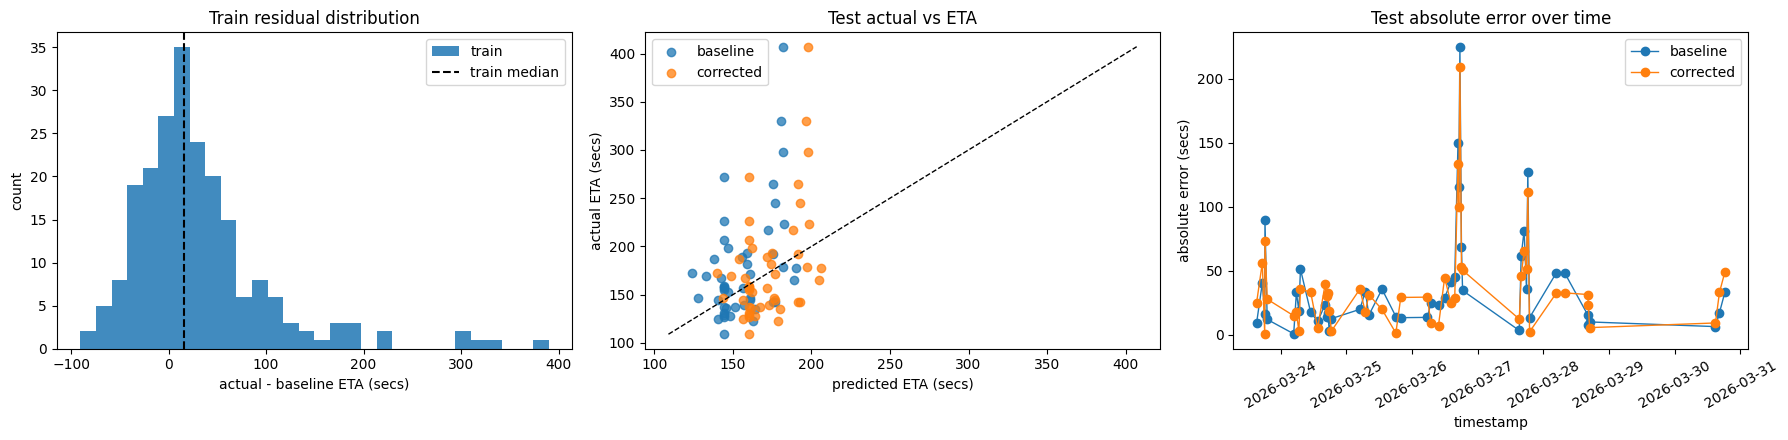

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(train_df["residual_secs"], bins=30, alpha=0.85, label="train")
axes[0].axvline(global_residual_secs, color="black", linestyle="--", label="train median")
axes[0].set_title("Train residual distribution")
axes[0].set_xlabel("actual - baseline ETA (secs)")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].scatter(test_df["baseline_eta_secs"], test_df["actual_eta_secs"], alpha=0.75, label="baseline")
axes[1].scatter(test_df["corrected_eta_secs"], test_df["actual_eta_secs"], alpha=0.75, label="corrected")
lo = float(min(test_df["baseline_eta_secs"].min(), test_df["corrected_eta_secs"].min(), test_df["actual_eta_secs"].min()))
hi = float(max(test_df["baseline_eta_secs"].max(), test_df["corrected_eta_secs"].max(), test_df["actual_eta_secs"].max()))
axes[1].plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1)
axes[1].set_title("Test actual vs ETA")
axes[1].set_xlabel("predicted ETA (secs)")
axes[1].set_ylabel("actual ETA (secs)")
axes[1].legend()

axes[2].plot(test_df["timestamp"], test_df["baseline_abs_error_secs"], marker="o", linewidth=1, label="baseline")
axes[2].plot(test_df["timestamp"], test_df["corrected_abs_error_secs"], marker="o", linewidth=1, label="corrected")
axes[2].set_title("Test absolute error over time")
axes[2].set_xlabel("timestamp")
axes[2].set_ylabel("absolute error (secs)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend()

plt.tight_layout()

## Save reusable artifacts

In [ ]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

all_predictions = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

prediction_columns = [
    "split",
    "timestamp",
    "stationId",
    "destination_stationId",
    "hour",
    "baseline_eta_secs",
    "actual_eta_secs",
    "residual_secs",
    "corrected_eta_secs",
    "baseline_abs_error_secs",
    "corrected_abs_error_secs",
]
predictions_path = ARTIFACT_DIR / "global_additive_correction_predictions.csv"
all_predictions[prediction_columns].to_csv(predictions_path, index=False)

model_card = {
    "model_name": "global_additive_correction",
    "target": "actual_eta_secs",
    "baseline_column": "estimate_time",
    "actual_column": "delta_time",
    "prediction_formula": "corrected_eta_secs = estimate_time + global_residual_secs",
    "correction_type": "median_train_residual",
    "global_residual_secs": global_residual_secs,
    "train_residual_mean_secs": global_residual_mean_secs,
    "split_strategy": "chronological_70_15_15",
    "data_path": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "split_summary": split_summary.assign(
        timestamp_min=split_summary["timestamp_min"].astype(str),
        timestamp_max=split_summary["timestamp_max"].astype(str),
    ).to_dict(orient="records"),
    "metrics": metrics_df.to_dict(orient="records"),
}

model_path = ARTIFACT_DIR / "global_additive_correction.json"
model_path.write_text(json.dumps(model_card, indent=2), encoding="utf-8")

pd.DataFrame(
    {
        "artifact": ["model_card", "predictions"],
        "path": [str(model_path.relative_to(PROJECT_ROOT)), str(predictions_path.relative_to(PROJECT_ROOT))],
    }
)